In [1]:
library(data.table)
library(stringr)
library(RColorBrewer)
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/')
devtools::load_all('utils/modules/R/phasingtools/')


i Loading phasingtools

Loading required package: ggplot2

Loading required package: Hmisc

Loading required package: lattice

Loading required package: survival

Loading required package: Formula


Attaching package: 'Hmisc'


The following objects are masked from 'package:base':

    format.pval, units


! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_site.R

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_pos.R



In [2]:
args <- list(
    in_dirs = ',data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr1-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr2-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr3-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr4-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr5-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr6-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr7-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr8-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr9-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr10-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr11-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr12-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr13-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr14-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr15-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr16-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr17-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr18-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr19-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr20-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr21-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr22-16xshort.qe',
    in_dir_merged = 'data/phased/wes_union_calls/merged'
    
)

In [3]:
dirs <- strsplit(args$in_dirs, split = ',')
files <- unlist(lapply(dirs, function(d){list.files(d, pattern = 'trio', full.names = TRUE)}))

In [4]:
    # organize by filename, chunks and extension
    M <- as.data.frame(do.call(rbind, strsplit(basename(files), split = '\\.')))
    colnames(M) <- c('param','n','ext')
    datasets = unique(M$param)

    # read each file and calculate average contribution of chunk
    comparison <- do.call(rbind, lapply(datasets, function(dname){

      regex_bool <- paste0('^',dname)
      selected_files <- files[grepl(regex_bool, basename(files))]

      ds <- lapply(selected_files, function(f) {
            d <- suppressWarnings(summarize_bcftools_trio_stats(fread(f)))
            d$chunk <- unlist(strsplit(str_match(f, ".of."), split = 'of'))[1]
            d$dataset <- dname
            d$chr <- str_extract(f, 'chr[0-9]+')
            return(d)
        })

      ds <- as.data.frame(do.call(rbind, ds))

      avg <- tail(ds)[1,]
      avg$n_tested <- sum(ds$n_tested)
      avg$n_switch <- sum(ds$n_switch)
      avg$n_mendel <- sum(ds$n_mendel)
      bconf <- Hmisc::binconf(avg$n_switch, avg$n_tested)
      est <- bconf[1]
      err <- abs(est - bconf[3])
      avg$ci_ser_est <- est
      avg$ci_ser_error <- err
      avg$ci_ser_est_pct <- NA
      avg$ci_ser_error_pct <- NA
      avg$chunk <- as.character('Average')

      ds <- rbind(ds, avg)

      return(ds)

    }))

In [5]:
 # get results from merged files
    # works only for chr20 for now!
    files_merge = list.files(args$in_dir_merged,
                   pattern = 'trio',
                   full.names = TRUE)[-1]

    dfs_merge <- do.call(rbind, lapply(files_merge, function(f){
        stopifnot(file.exists(f))
        merged <- suppressWarnings(summarize_bcftools_trio_stats(fread(f)))
        
        merged$dataset <- tools::file_path_sans_ext(basename(f))
        merged$chunk <- as.character("Merged")
        merged$chr <- str_extract(f, 'chr[0-9]+')
        return(merged)
    }))

In [6]:
 # combine data
    combined <- rbind(comparison, dfs_merge)

    max_chunks <- max(na.omit(as.numeric(as.character(combined$chunk))))
    myColors <- brewer.pal(max_chunks,"PiYG")
    myColors[10] <- 'grey'
    myColors[11] <- 'black'
    names(myColors) <- levels(combined$chunk)
    colScale <- scale_colour_manual(name = "chunk",values = myColors)

    # get values for vertical lines
    best_mrg <- combined[combined$chunk == 'Merged',]
    best_mrg <- best_mrg[best_mrg$ci_ser_est == min(best_mrg$ci_ser_est),]
    #best_avg <- combined[combined$chunk == 'Average',]
    #best_avg <- best_avg[best_avg$ci_ser_est == min(best_avg$ci_ser_est),]

    # convert into ordered factor (for plotting)
    combined$chunk <- factor(combined$chunk, levels = c(as.character(1:9),"Average","Merged"))
    combined$chr <- factor(combined$chr, levels = paste0("chr",1:22))

Warning message in na.omit(as.numeric(as.character(combined$chunk))):
"NAs introduced by coercion"


In [7]:
pd <- position_dodge(0.7)
    plt <- ggplot(combined,
           aes(
               x=100*ci_ser_est,
               xmax = 100*(ci_ser_est + ci_ser_error),
               xmin = 100*(ci_ser_est - ci_ser_error),
               y = chr,
               color = chunk
           )) +
        colScale +
        geom_vline(xintercept=best_mrg$ci_ser_est*100, linetype = 'dashed', col = 'black') +
        #geom_vline(xintercept=best_avg$ci_ser_est*100, linetype = 'dashed', color = 'black') +
        geom_point(stat='identity', position = pd, size = 2) +
        geom_errorbar(stat='identity', position = pd,width = 0.75) +
        ggtitle('Phasing accuracy across UKBB WES+CALLS',) +
        labs(color = "Phasing chunk(s)") +
        xlab('Switch Errors (%)') + ylab('') +
        theme_bw()

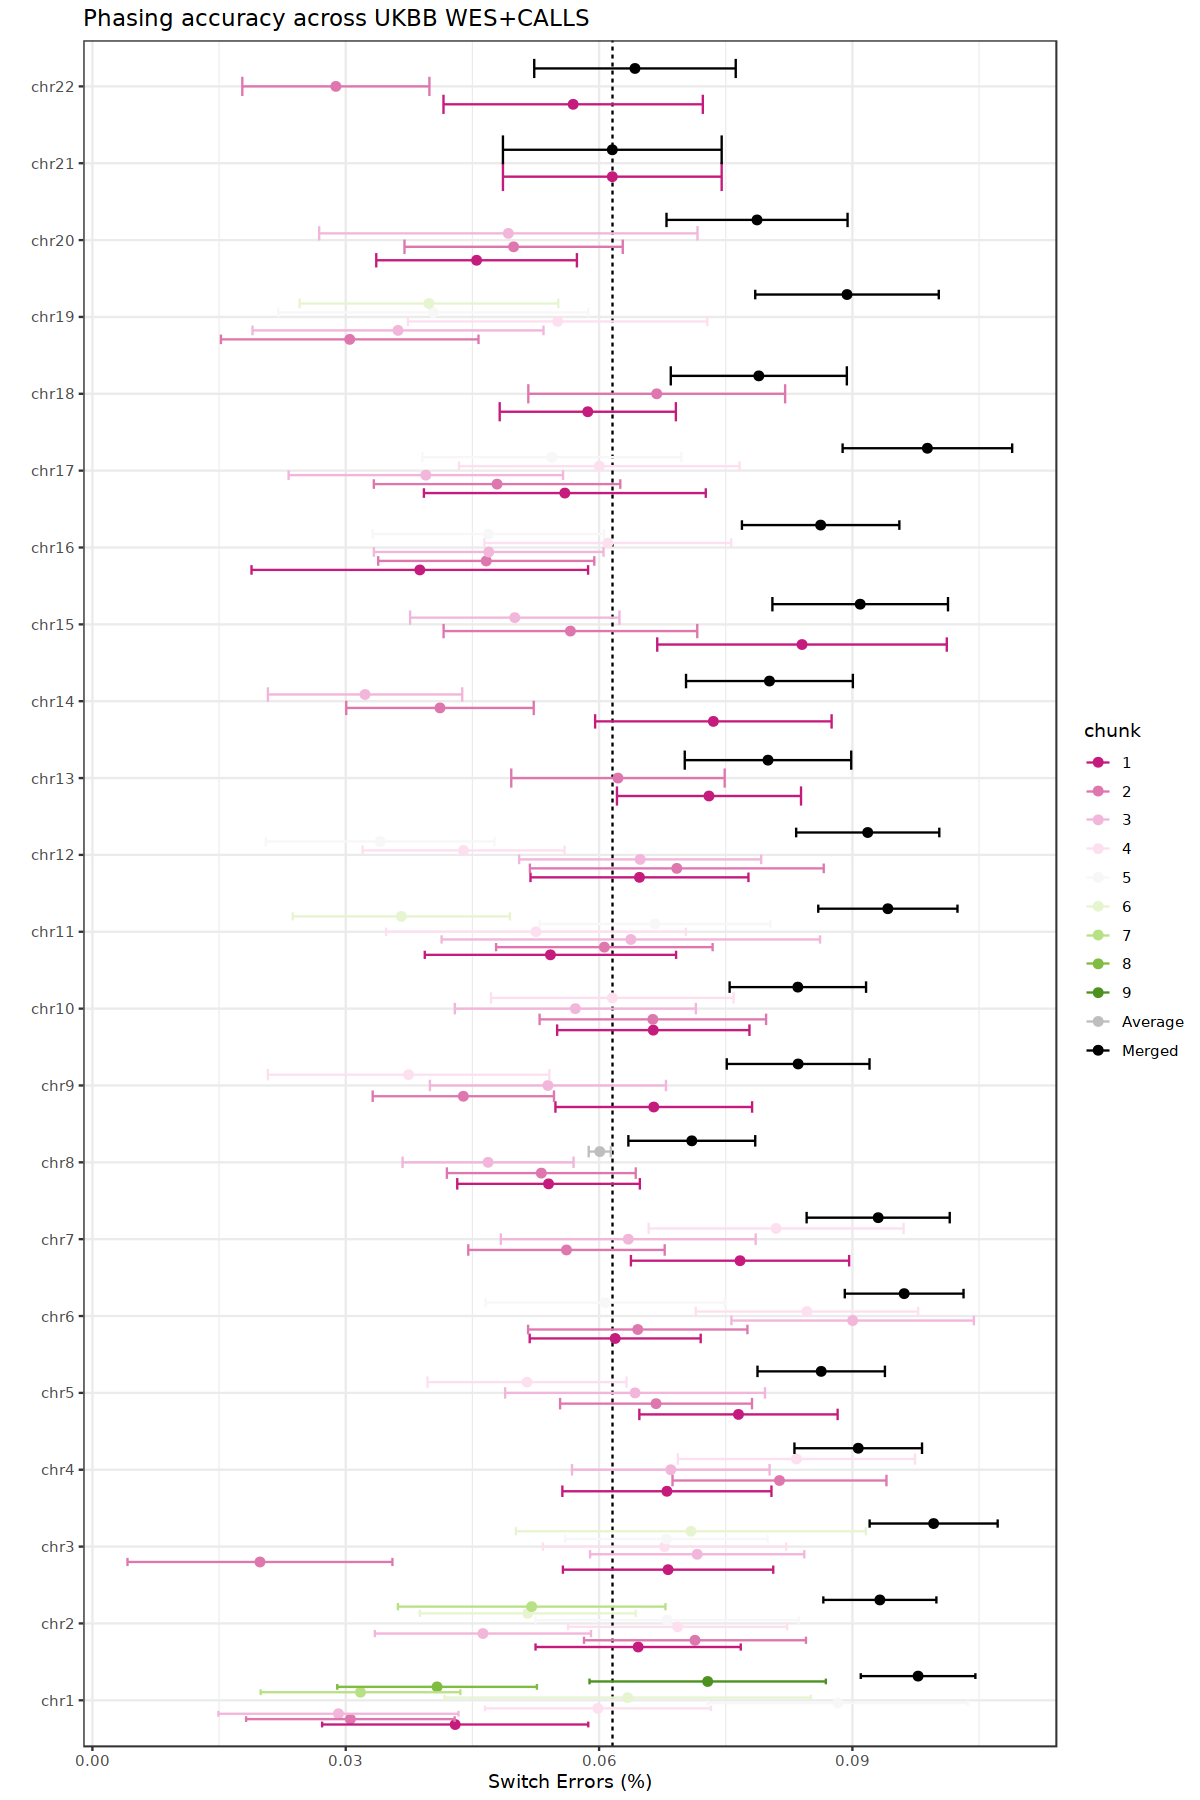

In [8]:
options(repr.plot.width=10, repr.plot.height=15)
plt

In [11]:
files <- list.files("data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr13-16xshort.qe", full.names = TRUE, pattern = '.txt')
lst <- lapply(files, function(f) {
    d <- fread(f)
    chunk <- unlist(strsplit(str_extract(f,'[0-9]+of[0-9]+'), split = 'of'))[1]
    d$chunk <- chunk
    d$cumsum <- cumsum(d$switches)
    return(d)
    })

In [12]:
ch <- do.call(rbind, lst)
unique(ch$chunk)

[1] "1" "2"

In [61]:
ligated <- list.files("data/phased/wes_union_calls/ligated", full.names = TRUE, pattern = '[0-9]+.txt')
ligated
dl <- fread(ligated[1])
dl$cumsum <- cumsum(dl$switches)
dl$chunk <- "ligated"


[1] "data/phased/wes_union_calls/ligated/ukb_eur_wes_union_calls_200k_chr13.txt"
[2] "data/phased/wes_union_calls/ligated/ukb_eur_wes_union_calls_200k_chr20.txt"

In [77]:
files <- sort(list.files(args$in_dir_merge, full.names = TRUE, pattern = '[0-9]+.txt'))
files[5]
#d <- fread('data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr21.txt')#fread(files[1])
d <- fread(files[5])
d$cumsum <- cumsum(d$switches)
d$chunk <- "Merged"


[1] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr13.txt"

In [78]:
mrg <- rbind(d, ch, dl)
max_chunks <- suppressWarnings(max(na.omit(as.numeric(as.character(mrg$chunk)))))
mrg$chunk <- factor(mrg$chunk, levels = as.character(c(1:max_chunks, "Merged","ligated")))

In [79]:
#mrg <- mrg[sample(1:nrow(mrg),size =  10000),]
#mrg <- mrg[mrg$POS > 2.7e+7 & mrg$POS < 2.8e+7]

In [80]:
#overlap <- fread('data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_1_overlap.txt')
#overlap$V4 <- as.numeric(gsub('(\\[)|(\\])','',overlap$V4))
#overlap$V5 <- as.numeric(gsub('(\\[)|(\\])','',overlap$V5))
#overlap$V6 <- overlap$V5 - overlap$V4

In [81]:
colors <- brewer.pal(max_chunks,"Blues")
colors[max_chunks + 1] <- 'orange'
colors[max_chunks + 2] <- 'darkred'
names(colors) <- levels(mrg$chunk)
scale_color <- scale_colour_manual(name = "chunk",values = colors)

Warning message in brewer.pal(max_chunks, "Blues"):
"minimal value for n is 3, returning requested palette with 3 different levels
"


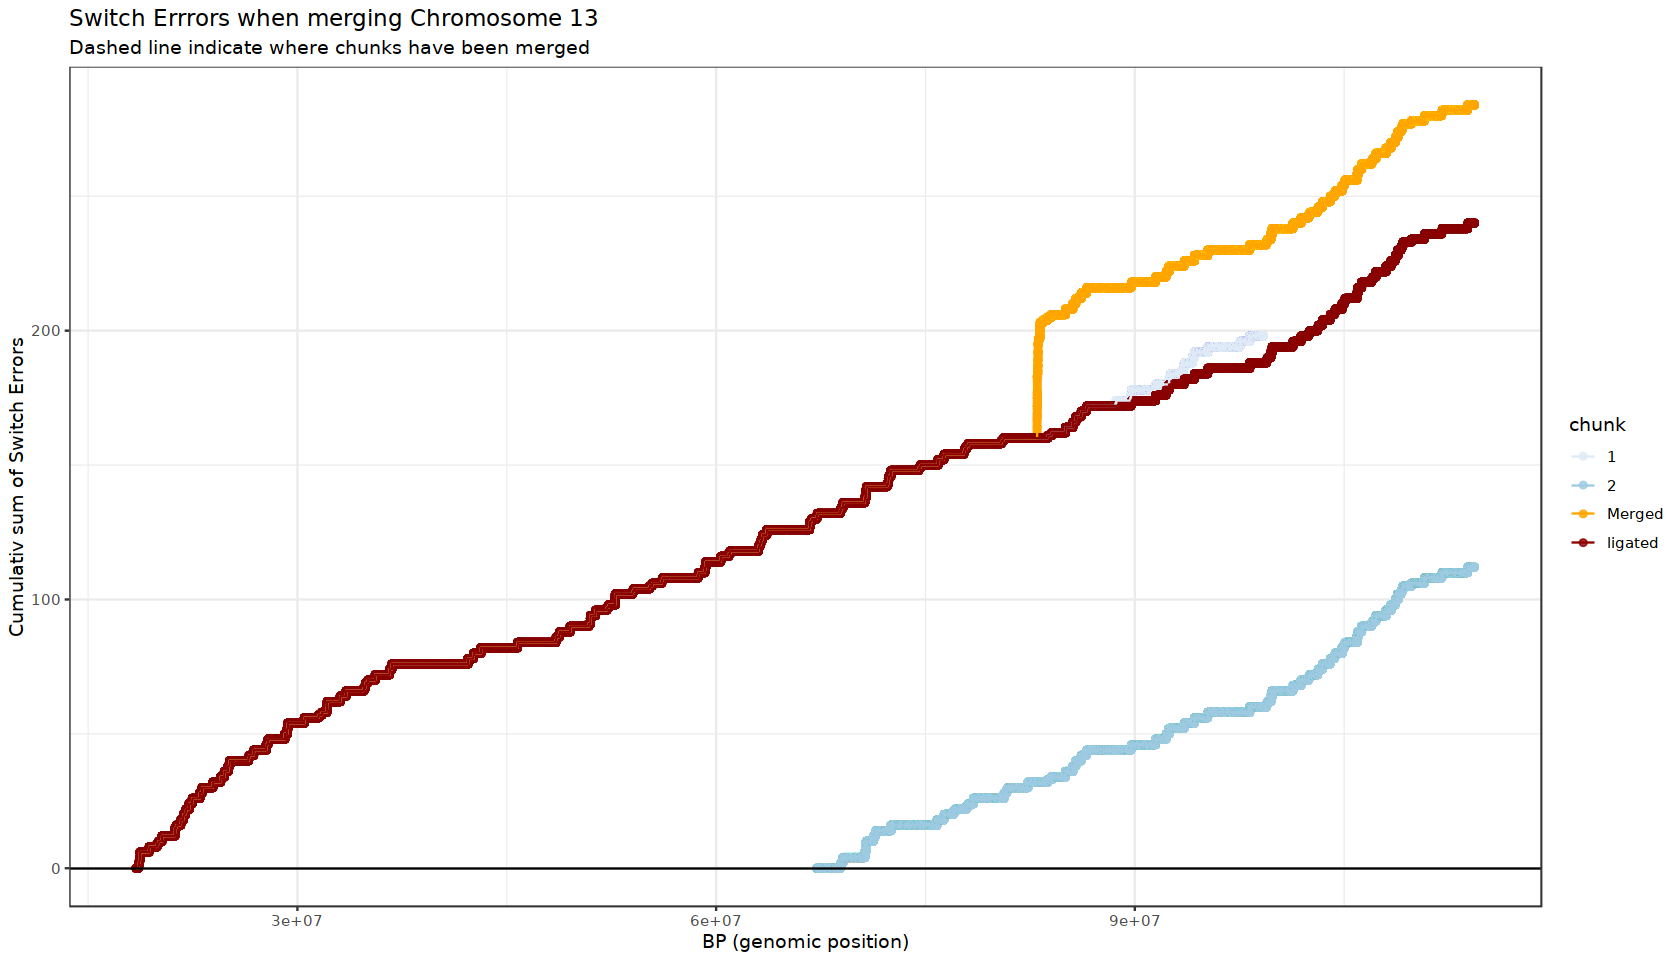

In [83]:
options(repr.plot.width=14, repr.plot.height=8)
ggplot(mrg, aes(x = POS, y = cumsum, group = chunk, color = chunk)) +
    geom_point(alpha = 0.8) +
    geom_line() +
    scale_color +
    geom_hline(yintercept = 0) +
    #geom_vline(xintercept=overlap$V4, linetype = 'dashed', color = 'grey') +
    #geom_vline(xintercept=overlap$V4, linetype = 'dashed', color = 'black') +
    xlab("BP (genomic position)") +
    ylab("Cumulativ sum of Switch Errors") +
    theme_bw() +
    ggtitle("Switch Errrors when merging Chromosome 13",
           "Dashed line indicate where chunks have been merged")

In [17]:
genes <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/protein_coding_genes.tsv')
genes <- genes[genes$chromosome_name == 1,]

do.call(rbind, lapply(overlap$V4, function(bp){
    gdf <- genes[genes$start_position < bp & bp < genes$end_position,]
    gdf$merge_slice_bp <- bp
    gdf$gene_len <- gdf$end_position - gdf$start_position
    return(gdf)
}))

ensembl_gene_id,hgnc_symbol,hgnc_id,chromosome_name,start_position,end_position,gene_biotype,merge_slice_bp,gene_len
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<int>
ENSG00000204478,PRAMEF20,HGNC:25224,1,13416351,13421328,protein_coding,13418190,4977
ENSG00000126705,AHDC1,HGNC:25230,1,27534035,27604431,protein_coding,27550983,70396
ENSG00000196517,SLC6A9,HGNC:11056,1,43991500,44031467,protein_coding,44001086,39967
ENSG00000122420,PTGFR,HGNC:9600,1,78303884,78540701,protein_coding,78499136,236817
ENSG00000196505,GDAP2,HGNC:18010,1,117863485,117929621,protein_coding,117920230,66136
ENSG00000162782,TDRD5,HGNC:20614,1,179591613,179691272,protein_coding,179654402,99659
ENSG00000076356,PLXNA2,HGNC:9100,1,208022242,208244384,protein_coding,208044623,222142


In [18]:
genes <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/protein_coding_genes.tsv')

In [19]:
genes$len <- genes$end_position - genes$start_position

In [20]:
quantile(genes$len, probs = 0.8)

80% 
82479.2